# Notebook 06 — TFT Forecast Radar
## Regime Transition Prediction

**Objective:**  
Train a Temporal Fusion Transformer to predict the probability of entering the High-volatility regime within 1, 3, and 5 trading days.

**How this differs from Notebook 05:**  
Notebook 05 predicted *return quantiles* (a regression task).  
This notebook predicts *regime transitions* (a binary classification task per horizon).  
The HMM regime labels become the **target**, not an input.

**Output:**  
Three calibrated probabilities per day:
```
transition_risk = {
    "1d": 0.12,
    "3d": 0.31,
    "5d": 0.44
}
```
These flow directly into the Market Weather JSON report.

## Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

from src.labeling import add_returns
from src.volatility import add_close_to_close_volatility
from src.features import add_lagged_returns, add_moving_average_features

import torch
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.models import TemporalFusionTransformer

print("Torch:", torch.__version__)
print("PL   :", pl.__version__)
print("GPU  :", "yes" if torch.cuda.is_available() else "no — cpu only")

Torch: 2.5.1+cu121
PL   : 2.6.1
GPU  : yes


## Load NIFTY 50 data and HMM regime labels

We load two things:
- Raw OHLCV -> build features the same way as all previous notebooks  
- `hmm_regimes_refit.csv` -> the HMM labels + state probabilities -> entropy
The entropy column was computed in Notebook 03 over the three state probabilities.  
We recompute it here cleanly so this notebook is self-contained.

In [2]:
# Raw price data
df = pd.read_csv(
    PROJECT_ROOT / "data/raw/nifty50.csv",
    parse_dates=["Date"]
)
df = df.sort_values("Date").reset_index(drop=True)

# Feature engineering => identical pipeline as all previous notebooks
df = add_returns(df)
df = add_close_to_close_volatility(df, window=20)
df = add_lagged_returns(df, lags=(1, 5, 10))
df = add_moving_average_features(df, windows=(5, 10, 20))

# HMM regime labels
reg = pd.read_csv(
    PROJECT_ROOT / "data/processed/hmm_regimes_refit.csv",
    parse_dates=["Date"]
)

df = df.merge(reg[["Date", "hmm_regime"]], on="Date", how="left")

print(df.shape)
print(df[["Date", "return", "vol_cc", "hmm_regime"]].tail())
print("\nRegime counts:")
print(df["hmm_regime"].value_counts())

(4521, 15)
           Date    return    vol_cc hmm_regime
4516 2026-02-13 -0.013023  0.138191     Medium
4517 2026-02-16  0.008309  0.141515        Low
4518 2026-02-17  0.001661  0.140728     Medium
4519 2026-02-18  0.003652  0.130728        Low
4520 2026-02-19 -0.014137  0.141139     Medium

Regime counts:
hmm_regime
Medium    1669
Low       1663
High      1169
Name: count, dtype: int64


## Construct binary transition targets

For each day `t` we ask three forward-looking questions:

| Target | Question |
|--------|----------|
| `target_1d` | Is the regime High at day t+1? |
| `target_3d` | Does the regime enter High *at any point* in t+1 to t+3? |
| `target_5d` | Does the regime enter High *at any point* in t+1 to t+5? |

Why "any point" and not just the exact day?  
Because from a risk perspective, knowing a crisis *arrives* within a window is more useful than knowing the exact day.  
A 5 day radar that says "40% chance of High within 5 days" is actionable even if the exact day is uncertain.

This is the key design difference from a simple next-day classifier.

In [3]:
def build_transition_targets(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    regime = (df["hmm_regime"] == "High").astype(int)

    # 1 day: is next day High?
    df["target_1d"] = regime.shift(-1)

    # 3 day: is High reached within next 3 days?
    df["target_3d"] = (
        pd.concat([regime.shift(-i) for i in range(1, 4)], axis=1)
        .max(axis=1)
    )

    # 5 day: is High reached within next 5 days?
    df["target_5d"] = (
        pd.concat([regime.shift(-i) for i in range(1, 6)], axis=1)
        .max(axis=1)
    )

    return df

df = build_transition_targets(df)

print("Target class balance:")
for col in ["target_1d", "target_3d", "target_5d"]:
    pos = df[col].mean()
    print(f"  {col}: {pos:.1%} positive (High transition)")

Target class balance:
  target_1d: 25.9% positive (High transition)
  target_3d: 26.8% positive (High transition)
  target_5d: 27.8% positive (High transition)


## Assemble the TFT feature set and add entropy

We use "hmm_regime" (the raw string column: "Low" / "Medium" / "High") directly as the categorical input.
pytorch-forecasting requires categoricals to be string dtype — no integer encoding needed.
We also add "vol_cc_lag_1" which was in the previous TFT notebook and is meaningful for sequence modelling.

In [4]:
# lag-1 volatility (used in prior notebooks)
df["vol_cc_lag_1"] = df["vol_cc"].shift(1)

# Drop rows with NaN from rolling windows and forward targets
feature_cols = [
    "return", "vol_cc", "vol_cc_lag_1",
    "ret_lag_1", "ret_lag_5", "ret_lag_10",
    "ma_ratio_5", "ma_ratio_10", "ma_ratio_20",
]

df = df.dropna(subset=feature_cols + ["target_1d", "target_3d", "target_5d"])
df = df.reset_index(drop=True)

# TFT requires integer time index and a group id
df["time_idx"] = df.index.astype(int)
df["series"]   = "NIFTY50"  # single series, extended later per ETF

# Targets must be integer for BCEWithLogitsLoss loss
for col in ["target_1d", "target_3d", "target_5d"]:
    df[col] = df[col].astype(int)

print(f"Final dataset: {len(df)} rows")
print(f"Date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")
print(df[feature_cols + ["hmm_regime", "target_1d", "target_3d", "target_5d"]].tail(3))

Final dataset: 4499 rows
Date range: 2007-10-17 -> 2026-02-18
        return    vol_cc  vol_cc_lag_1  ret_lag_1  ret_lag_5  ret_lag_10  \
4496  0.008309  0.141515      0.138191  -0.013023   0.006757   -0.009172   
4497  0.001661  0.140728      0.141515   0.008309   0.002623    0.025476   
4498  0.003652  0.130728      0.140728   0.001661   0.000721    0.001883   

      ma_ratio_5  ma_ratio_10  ma_ratio_20 hmm_regime  target_1d  target_3d  \
4496    0.996614     0.997166     1.006737        Low          0          0   
4497    0.999897     0.998830     1.008133     Medium          0          0   
4498    1.004599     1.002309     1.010652        Low          0          0   

      target_5d  
4496          0  
4497          0  
4498          0  


## Chronological train / validation split

We use an 80/20 chronological split — identical to all previous notebooks.  
No shuffling. Financial time series must never be split randomly.

In [5]:
split_idx = int(len(df) * 0.80)

train_df = df.iloc[:split_idx].copy()
val_df   = df.iloc[split_idx:].copy()

print(f"Train: {len(train_df)} rows  ({train_df['Date'].min().date()} -> {train_df['Date'].max().date()})")
print(f"Val  : {len(val_df)} rows  ({val_df['Date'].min().date()} -> {val_df['Date'].max().date()})")

Train: 3599 rows  (2007-10-17 -> 2022-06-28)
Val  : 900 rows  (2022-06-29 -> 2026-02-18)


## Build TFT datasets — one model per horizon

We train three independent TFT models, one for each horizon (1d, 3d, 5d).  
This is simpler and more interpretable than a multi-output model.  
Each model is a binary classifier: does a High-regime transition occur within N days?

**Key TFT parameters:**
- `max_encoder_length = 30` — the 30-day lookback window  
- `max_prediction_length = 1` — we predict one output value (the transition probability)  
- `target` = binary 0/1 per horizon  
- Loss = `CrossEntropy` (pytorch-forecasting's built-in binary/multiclass loss)

In [6]:
from pytorch_forecasting.data.encoders import NaNLabelEncoder

MAX_ENCODER = 30
MAX_PRED    = 1

UNKNOWN_REALS = [
    "return", "vol_cc", "vol_cc_lag_1",
    "ret_lag_1", "ret_lag_5", "ret_lag_10",
    "ma_ratio_5", "ma_ratio_10", "ma_ratio_20",
]

CATEGORICALS = ["hmm_regime"]


def make_dataset(train_df, val_df, target_col):
    training = TimeSeriesDataSet(
        train_df,
        time_idx               = "time_idx",
        target                 = target_col,
        group_ids              = ["series"],
        max_encoder_length     = MAX_ENCODER,
        max_prediction_length  = MAX_PRED,
        time_varying_unknown_reals      = UNKNOWN_REALS,
        time_varying_known_reals        = ["time_idx"],
        time_varying_known_categoricals = CATEGORICALS,
        target_normalizer      = None,
        categorical_encoders   = {"hmm_regime": NaNLabelEncoder(add_nan=False)},
    )

    # predict=True collapses to 1 sample per group — do not use it here.
    # We want every valid window in val_df as a separate sample.
    validation = TimeSeriesDataSet.from_dataset(
        training, val_df,
        stop_randomization=True
    )
    return training, validation


datasets = {}
for horizon in ["target_1d", "target_3d", "target_5d"]:
    tr, va = make_dataset(train_df, val_df, horizon)
    datasets[horizon] = (tr, va)
    print(f"{horizon}: dataset built -- "
          f"{len(tr)} train samples, {len(va)} val samples")


target_1d: dataset built -- 3569 train samples, 870 val samples
target_3d: dataset built -- 3569 train samples, 870 val samples
target_5d: dataset built -- 3569 train samples, 870 val samples


## Train the three TFT models

We keep the architecture deliberately small — this matches what worked in Notebook 05 and avoids overfitting on a single index series.

`pos_weight` compensates for class imbalance. If High-transition days are 20% of data, `pos_weight = (1-0.20)/0.20 = 4.0` tells the loss to penalise missed positives 4× more than false alarms.

In [7]:
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pytorch_forecasting.metrics import MAE


def get_pos_weight(df, target_col):
    pos = df[target_col].mean()
    return torch.tensor((1 - pos) / (pos + 1e-9))


def train_tft(training_ds, val_ds, target_col, max_epochs=20):
    pos_weight = get_pos_weight(train_df, target_col)
    print(f"  pos_weight for {target_col}: {pos_weight:.2f}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # MAE is used only to satisfy from_dataset() -- our custom loop below
    # uses BCEWithLogitsLoss and never calls the built-in training step
    tft = TemporalFusionTransformer.from_dataset(
        training_ds,
        learning_rate          = 0.01,
        hidden_size            = 16,
        attention_head_size    = 1,
        dropout                = 0.1,
        hidden_continuous_size = 8,
        output_size            = 1,
        loss                   = MAE(),
        log_interval           = -1,
    )
    tft = tft.to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    optimizer = Adam(tft.parameters(), lr=0.01)
    scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    train_loader = training_ds.to_dataloader(train=True,  batch_size=64, num_workers=0)
    val_loader   = val_ds.to_dataloader(train=False, batch_size=64, num_workers=0)

    best_val_loss = float("inf")
    best_state    = None

    for epoch in range(max_epochs):
        tft.train()
        train_loss = 0.0
        for x, (y, _) in train_loader:
            x = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in x.items()}
            y = y.to(device).float()
            optimizer.zero_grad()
            out    = tft(x)
            logits = out["prediction"].squeeze(-1)
            loss   = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(tft.parameters(), 0.1)
            optimizer.step()
            train_loss += loss.item()

        tft.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, (y, _) in val_loader:
                x = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in x.items()}
                y = y.to(device).float()
                out    = tft(x)
                logits = out["prediction"].squeeze(-1)
                val_loss += criterion(logits, y).item()

        scheduler.step(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f"  epoch {epoch+1:02d} | "
                  f"train {train_loss/len(train_loader):.4f} | "
                  f"val {val_loss/len(val_loader):.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in tft.state_dict().items()}

    tft.load_state_dict(best_state)
    tft = tft.to(device)
    print(f"  best val loss: {best_val_loss/len(val_loader):.4f}")
    return tft


models = {}
for horizon, (tr_ds, va_ds) in datasets.items():
    print(f"\nTraining {horizon}...")
    models[horizon] = train_tft(tr_ds, va_ds, horizon)
    print(f"  done.")



Training target_1d...
  pos_weight for target_1d: 2.20
  epoch 05 | train 0.0786 | val 0.0501
  epoch 10 | train 0.0728 | val 0.0471
  epoch 15 | train 0.0666 | val 0.0490
  epoch 20 | train 0.0655 | val 0.0469
  best val loss: 0.0444
  done.

Training target_3d...
  pos_weight for target_3d: 2.10
  epoch 05 | train 0.1499 | val 0.2601
  epoch 10 | train 0.1237 | val 0.0962
  epoch 15 | train 0.0970 | val 0.0969
  epoch 20 | train 0.0637 | val 0.0952
  best val loss: 0.0846
  done.

Training target_5d...
  pos_weight for target_5d: 2.00
  epoch 05 | train 0.1704 | val 0.1509
  epoch 10 | train 0.1326 | val 0.1647
  epoch 15 | train 0.0793 | val 0.1762
  epoch 20 | train 0.0653 | val 0.1972
  best val loss: 0.1288
  done.


## Evaluation — AUC-ROC and calibration

We evaluate each model with two metrics:

**AUC-ROC** — measures discrimination (can the model separate transition days from non-transition days?).  
Random = 0.5, perfect = 1.0. We want > 0.60 to be useful.

**Calibration curve** — measures honesty (when the model says 30%, does High actually occur ~30% of the time?).  
This is critical for a risk display. An uncalibrated model that says "80% risk" when the real rate is 20% is dangerous.

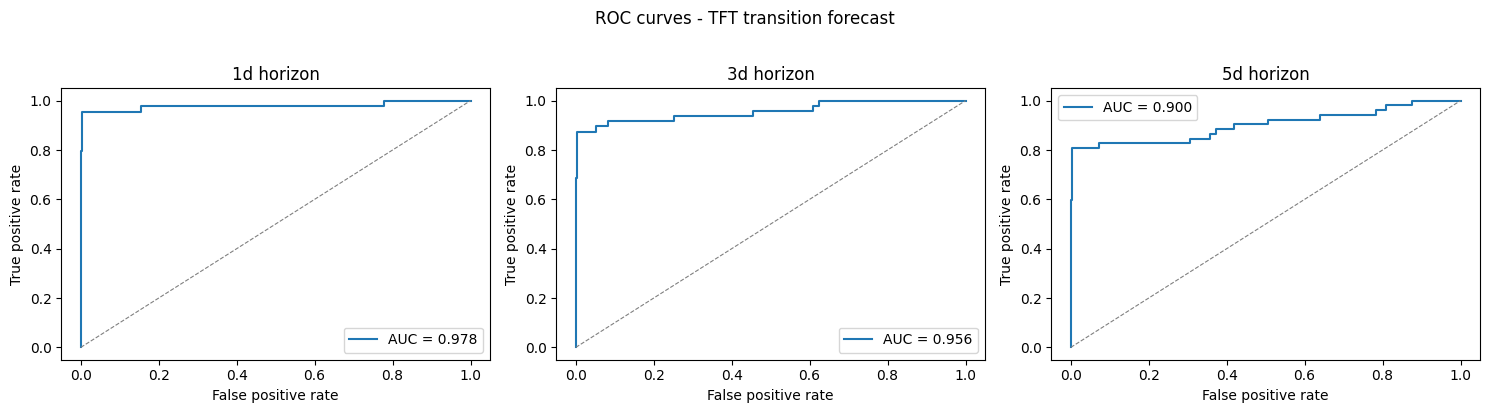


AUC-ROC summary:
  target_1d: 0.978  [good]
  target_3d: 0.956  [good]
  target_5d: 0.900  [good]


In [8]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (horizon, (tr_ds, va_ds)) in zip(axes, datasets.items()):
    val_loader = va_ds.to_dataloader(train=False, batch_size=64, num_workers=0)

    model = models[horizon].eval().to(device)
    all_probs, all_actuals = [], []

    with torch.no_grad():
        for x, (y, _) in val_loader:
            x = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in x.items()}
            out = model(x)
            logits = out["prediction"].squeeze(-1)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.flatten().tolist())
            all_actuals.extend(y.numpy().flatten().tolist())

    probs   = np.array(all_probs)
    actuals = np.array(all_actuals).astype(int)

    auc = roc_auc_score(actuals, probs)
    results[horizon] = {"auc": auc, "probs": probs, "actuals": actuals}

    fpr, tpr, _ = roc_curve(actuals, probs)
    ax.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    ax.plot([0,1], [0,1], "--", color="gray", linewidth=0.8)
    ax.set_title(horizon.replace("target_", "") + " horizon")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend()

plt.suptitle("ROC curves - TFT transition forecast", y=1.02)
plt.tight_layout()
plt.show()

print("\nAUC-ROC summary:")
for h, r in results.items():
    flag = "good" if r["auc"] > 0.60 else "weak"
    print(f"  {h}: {r['auc']:.3f}  [{flag}]")


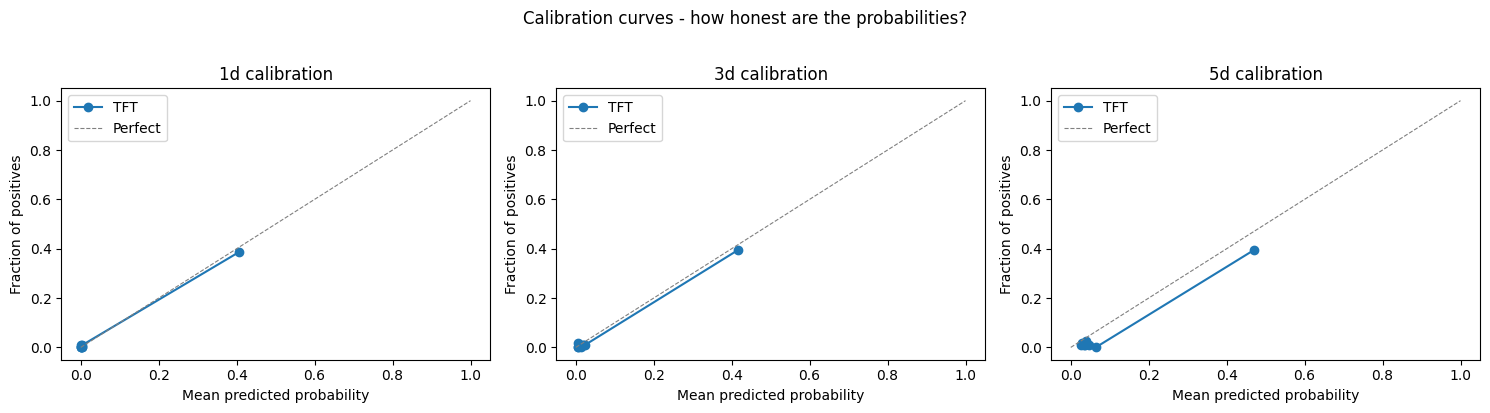

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (horizon, r) in zip(axes, results.items()):
    fraction, mean_pred = calibration_curve(
        r["actuals"], r["probs"], n_bins=8, strategy="quantile"
    )
    ax.plot(mean_pred, fraction, marker="o", label="TFT")
    ax.plot([0,1], [0,1], "--", color="gray", linewidth=0.8, label="Perfect")
    ax.set_title(horizon.replace("target_", "") + " calibration")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend()

plt.suptitle("Calibration curves - how honest are the probabilities?", y=1.02)
plt.tight_layout()
plt.show()


## Inspect sample predictions

Look at a 30 row window from the validation set and see what the model actually outputs day by day.  
We want to see probabilities rising *before* a confirmed High-regime period — that's the radar working.

In [10]:
horizon = "target_5d"
r = results[horizon]

sample = val_df.copy().reset_index(drop=True)
n = min(len(r["probs"]), len(sample))
sample = sample.iloc[:n].copy()
sample["pred_prob_5d"] = r["probs"][:n]
sample["actual_5d"]    = r["actuals"][:n]

# Show windows around actual High transitions
transitions = sample[sample["actual_5d"] == 1].head(3).index.tolist()

for idx in transitions:
    window = sample.iloc[max(0, idx-5): idx+6]
    print(window[["Date", "hmm_regime", "pred_prob_5d", "actual_5d"]].to_string())
    print()

          Date hmm_regime  pred_prob_5d  actual_5d
433 2024-04-02        Low      0.038150          0
434 2024-04-03     Medium      0.028793          0
435 2024-04-04        Low      0.036878          0
436 2024-04-05     Medium      0.027385          0
437 2024-04-08        Low      0.035115          0
438 2024-04-09     Medium      0.028118          1
439 2024-04-10        Low      0.036090          1
440 2024-04-12     Medium      0.026628          1
441 2024-04-15        Low      0.041875          1
442 2024-04-16     Medium      0.041403          1
443 2024-04-18        Low      0.949929          1

          Date hmm_regime  pred_prob_5d  actual_5d
434 2024-04-03     Medium      0.028793          0
435 2024-04-04        Low      0.036878          0
436 2024-04-05     Medium      0.027385          0
437 2024-04-08        Low      0.035115          0
438 2024-04-09     Medium      0.028118          1
439 2024-04-10        Low      0.036090          1
440 2024-04-12     Medium     

## Threshold analysis for the dashboard display

The dashboard will show a risk level: Low / Moderate / High alert.  
We need to decide what probability threshold maps to each level.

We use the F1 maximising threshold as the operational cutoff, but display the raw probability on the dashboard so users can judge for themselves.

In [11]:
from sklearn.metrics import f1_score, precision_score, recall_score

print("Threshold sweep for each horizon:\n")

for horizon, r in results.items():
    best_f1, best_thresh = 0, 0.5
    for thresh in np.arange(0.1, 0.9, 0.05):
        preds_bin = (r["probs"] >= thresh).astype(int)
        f1 = f1_score(r["actuals"], preds_bin, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh

    preds_bin = (r["probs"] >= best_thresh).astype(int)
    print(f"{horizon}:")
    print(f"  Best threshold : {best_thresh:.2f}")
    print(f"  F1             : {best_f1:.3f}")
    print(f"  Precision      : {precision_score(r['actuals'], preds_bin, zero_division=0):.3f}")
    print(f"  Recall         : {recall_score(r['actuals'], preds_bin, zero_division=0):.3f}")
    print()

Threshold sweep for each horizon:

target_1d:
  Best threshold : 0.15
  F1             : 0.955
  Precision      : 0.955
  Recall         : 0.955

target_3d:
  Best threshold : 0.25
  F1             : 0.913
  Precision      : 0.955
  Recall         : 0.875

target_5d:
  Best threshold : 0.40
  F1             : 0.875
  Precision      : 0.955
  Recall         : 0.808



## Save trained models

We save the three TFT models to `models/tft/` so the production pipeline can load them without retraining.  
Each model is saved as a full checkpoint (weights + hyperparameters).

In [12]:
save_dir = PROJECT_ROOT / "models" / "tft"
save_dir.mkdir(parents=True, exist_ok=True)

for horizon, model in models.items():
    path = save_dir / f"tft_{horizon}.pt"
    torch.save(model.state_dict(), path)
    print(f"Saved: {path}")

print("\nAll models saved to models/tft/")


Saved: C:\Users\Aryavart\stock-regime-ml\models\tft\tft_target_1d.pt
Saved: C:\Users\Aryavart\stock-regime-ml\models\tft\tft_target_3d.pt
Saved: C:\Users\Aryavart\stock-regime-ml\models\tft\tft_target_5d.pt

All models saved to models/tft/
